# Прогнозирование сумм платежей с помощью catboost (+ SARIMAX)

Прогнозируем суммы платежей в различных формах - суммы платежей суммарно на следующие день/неделю/месяц, также с группировкой по различным описательным признакам (фонды, провайдеры платежей, тип подписки, категории платежей).

На **текущем этапе** данные подготовлены для прогнозирования сумм исходя из описательных признаков c учетом временной составляющей (прогноза SARIMAX как дополнительный признак) и группировки по признакам.

<a id='К-содержанию'></a>
**Содержание проекта** \
[Загрузка и предобработка данных](#Загрузка-и-предобработка-данных)\
[Подготовка данных, агрегирование и генерация доппризнаков для прогнозирования сумм платежей](#Подготовка-данных,-агрегирование-и-генерация-доппризнаков-для-прогнозирования-сумм-платежей)\
[Обучение SARIMAX и прогнозирование признака для Catboost](#Обучение-SARIMAX-и-прогнозирование-признака-для-Catboost)\
[Обучение Catboost](#Обучение-Catboost)\
[Тестирование модели с визуализацией прогноза](#Тестирование-модели-с-визуализацией-прогноза)



In [1]:
%%capture
!pip install catboost
!pip install category_encoders

In [2]:
#импортируем библиотеки перед началом проекта одним блоком
import os
import pandas as pd
import numpy as np
import random
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# загружаем класс pipeline и классы дя подготовки данных и запуска пайплайна
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from tqdm import notebook
from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# загружаем нужные модели и метрики
from catboost import CatBoostRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer
from statsmodels.tsa.statespace.sarimax import SARIMAX

import torch


In [3]:
# вынесем блок с настройками и функциями

# зададим стандарт датафрейма перед загрузкой
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('future.no_silent_downcasting', True)

# устанавливаем фиксированное значение для всех случайных библиотек
RANDOM_STATE = 42

def seed_all(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False
seed_all(RANDOM_STATE)

def smape(y_true, y_pred):
    return 100 * np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2))

# cоздаём метрику smape
smape_scorer = make_scorer(smape, greater_is_better=False)

<a id='Загрузка-и-предобработка-данных'></a> 
## Загрузка и предобработка данных
[К содержанию](#К-содержанию)

In [4]:
# импортируем тренировочные данные
pth1 = 'data.csv'

if os.path.exists(pth1):
    data = pd.read_csv(pth1)
else:
    print('Something is wrong')

data.info()
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360258 entries, 0 to 360257
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   fund_id     360258 non-null  int64  
 1   full_sum    360258 non-null  float64
 2   date        360258 non-null  int64  
 3   provider    360258 non-null  int64  
 4   signup      360258 non-null  int64  
 5   category_1  360258 non-null  int64  
 6   category_2  360258 non-null  int64  
 7   category_3  360258 non-null  int64  
 8   category_4  360258 non-null  int64  
 9   category_5  360258 non-null  int64  
 10  category_6  360258 non-null  int64  
 11  category_7  360258 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 33.0 MB


,fund_id,full_sum,date,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7
0,44,500.00,1508393717,4,0,0,0,0,0,0,0,0
1,88,200.00,1508399528,4,0,0,0,0,0,0,0,0
2,1,100.00,1508400025,4,0,0,0,0,0,0,0,0
3,1,100.00,1508400043,4,0,0,0,0,0,0,0,0
4,1,20.00,1508400088,4,0,0,0,0,0,0,0,0


In [5]:
# посмотрим распределение меток по категориям
cat_columns = ['category_1', 'category_2', 'category_3', 'category_4', 'category_5', 'category_6', 'category_7']

data['cat_columns_sum'] = data[cat_columns].sum(axis=1)
display(data['cat_columns_sum'].value_counts())

data = data.drop(['cat_columns_sum'],axis=1)

cat_columns_sum
0    321861
1     21656
2     10219
3      6522
Name: count, dtype: int64

In [6]:
# проверим дубликаты
print('Количество дубликатов: ', data.duplicated().sum().sum())

# проверим пропуски
print('Количество пропусков: ', data.isna().sum().sum())

# уберем дубликаты и пропуски
data = data.drop_duplicates()
data = data.dropna()

Количество дубликатов:  2989
Количество пропусков:  0


In [7]:
# исключаем мегавыбросы (платежи более порога TRESHOLD_CONST) 
# для более адекватного обучения модели 

TRESHOLD_CONST = 0.95

threshold = data['full_sum'].quantile(TRESHOLD_CONST)
data = data[data['full_sum']<=threshold]

Выловили порядка 3 тысяч дубликатов, что с одной стороны маловероятно - одинаковые платежи в одну и ту же секунду, но, возможно, банк обработал платежи одним пакетом, с точки зрения обучения дубликаты не несут дополнительной информации, поэтому их удалили.  
Выбросы на суммы платежей более порога 95%-перцентиля рублей также исключили.


In [8]:
# по датам добавим столбец в наглядном формате datetime
data['datetime'] = pd.to_datetime(data['date'], unit='s')
data = data.drop('date', axis=1)

data.head() 

,fund_id,full_sum,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,datetime
0,44,500.00,4,0,0,0,0,0,0,0,0,2017-10-19 06:15:17
1,88,200.00,4,0,0,0,0,0,0,0,0,2017-10-19 07:52:08
2,1,100.00,4,0,0,0,0,0,0,0,0,2017-10-19 08:00:25
3,1,100.00,4,0,0,0,0,0,0,0,0,2017-10-19 08:00:43
4,1,20.00,4,0,0,0,0,0,0,0,0,2017-10-19 08:01:28


<a id='Подготовка-данных,-агрегирование-и-генерация-доппризнаков-для-прогнозирования-сумм-платежей'></a> 
## Подготовка данных, агрегирование и генерация доппризнаков для прогнозирования сумм платежей
[К содержанию](#К-содержанию)

In [9]:
# выберем фонд
data_fund = data[data['fund_id']==136] #136

data_fund.info()
data_fund.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3924 entries, 527 to 360131
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fund_id     3924 non-null   int64         
 1   full_sum    3924 non-null   float64       
 2   provider    3924 non-null   int64         
 3   signup      3924 non-null   int64         
 4   category_1  3924 non-null   int64         
 5   category_2  3924 non-null   int64         
 6   category_3  3924 non-null   int64         
 7   category_4  3924 non-null   int64         
 8   category_5  3924 non-null   int64         
 9   category_6  3924 non-null   int64         
 10  category_7  3924 non-null   int64         
 11  datetime    3924 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(10)
memory usage: 398.5 KB


,fund_id,full_sum,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,datetime
527,136,100.00,5,1,0,0,1,0,0,0,0,2017-10-20 09:47:44
708,136,200.00,1,1,0,0,1,0,0,0,0,2017-10-20 14:40:08
15185,136,200.00,1,1,0,0,1,0,0,0,0,2017-11-02 14:19:13
15535,136,400.00,1,0,0,0,1,0,0,0,0,2017-11-02 22:45:43
16267,136,1000.00,1,0,0,0,1,0,0,0,0,2017-11-03 17:35:34


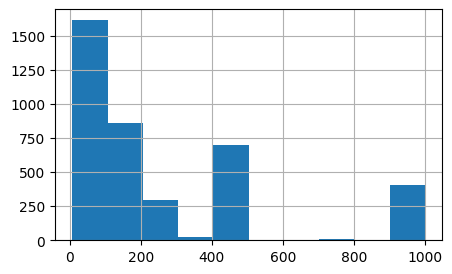

In [10]:
data_fund['full_sum'].hist(bins=10,figsize=(5, 3));

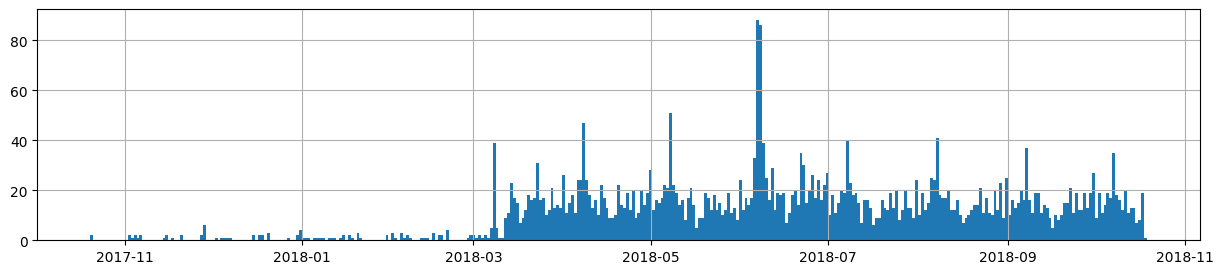

In [11]:
data_fund['datetime'].dt.date.hist(bins=365, figsize=(15, 3));

In [12]:
data_fund = data_fund.drop('fund_id', axis=1)
#data_fund = data_fund.drop('provider', axis=1)
data_fund = data_fund.drop(['category_1', 'category_2','category_3', 'category_4', 'category_5', 'category_6', 'category_7'], axis=1) # признаки с нулевым влиянием - исключаем

# проверяем монотонность и сортируем при необходимости
if not data_fund['datetime'].is_monotonic_increasing:
    data_fund = data_fund.sort_values('datetime')

data_fund.head(1)

,full_sum,provider,signup,datetime
527,100.00,5,1,2017-10-20 09:47:44


In [13]:
# функция  агрегации и добавления признаков
def agg_add_features_data_fund(data, rolling_window=2):
        
        data = data.copy()
        
        # добавляем столбец с датой
        data['date'] = data['datetime'].dt.floor('D')  # сохраняем формат datetime64[ns]
        

        # перед агрегацией заполняем пропуски нулевыми строками
        date_range = pd.date_range(start=data['date'].min(), end=data['date'].max())
        data_full = pd.DataFrame({'date': date_range})
        # объединяем исходные данные с полным списком дат
        data = data_full.merge(data, on='date', how='left')
        # для datetime используем значение из date
        data['datetime'] = data['datetime'].fillna(data['date'])
        # остальные столбцы заполняем нулями
        numeric_columns = data.columns.difference(['date', 'datetime'])
        data[numeric_columns] = data[numeric_columns].fillna(0)
        

        # добавляем столбцы с днем недели и номером недели в месяце
        data['day_of_week'] = data['datetime'].dt.weekday.astype('str')
        #data['week_number'] = data_fund['datetime'].dt.isocalendar().week.astype('str')  # Номер недели
        data['week_number'] = data['datetime'].dt.day.sub(1).floordiv(7).add(1)

        
        # кодируем признак 'provider'
        enc = OneHotEncoder(drop='first', sparse_output=False)
        encoded_provider = enc.fit_transform(data[['provider']])
        # переводим в датафейм и объединяем с исходными данными
        encoded_df = pd.DataFrame(encoded_provider, columns=enc.get_feature_names_out(['provider']), index=data.index)
        data = pd.concat([data.drop(columns=['provider']), encoded_df], axis=1)
        

        # определяем список столбцов для агрегации (все, кроме группировочного и временных)
        columns_to_aggregate = data.columns.difference(['date','datetime','day_of_week', 'week_number'])

        # делаем агрегацию исходных данных
        aggregated_data = data.groupby('date')[columns_to_aggregate].sum()
        aggregated_data.index.name = None

        # генерируем доппризнаки
        added_features = data.groupby('date').agg(
        count_payments=('full_sum', 'count'),  # количество платежей
        avg_payment=('full_sum', 'mean'),  # средний размер платежа
        median_payment=('full_sum', 'median'),  # медианный платеж
        min_payment=('full_sum', 'min'),  # минимальный платеж
        max_payment=('full_sum', 'max'),  # максимальный платеж
        day_of_week=('day_of_week', 'first'),  # день недели
        week_number=('week_number', 'first')  # номер недели
        )
        added_features.index.name = None
        
        # добавим скользящее среднее по платежам за последние n дней (например, 7 дней), исключая текущий день
        added_features['rolling_avg_payment'] = (added_features['avg_payment'].shift(1)
                                                 .rolling(window=rolling_window, min_periods=1)
                                                 .mean()
                                                 )

        # добавляем лаги на 1-7 дней
        for lag in range(1, 8):
                added_features[f'lag_{lag}_full_sum'] = aggregated_data['full_sum'].shift(lag)

        # Объединяем aggregated_data и added_features по индексу
        final_data = aggregated_data.join(added_features, how='left')
        final_data = final_data.dropna()

        # корректируем счетчик платежей, т.к. выше добавляли пустые строки для заполнения пропущенных дат
        final_data['count_payments'] = final_data.apply(lambda x: 0 if x['full_sum'] == 0 else x['count_payments'], axis=1)

        return final_data

# преобразовываем датасет
final_data_fund = agg_add_features_data_fund(data_fund)

display(final_data_fund.shape,
        final_data_fund.head(2))


(358, 21)

,full_sum,provider_1.0,provider_3.0,provider_4.0,provider_5.0,signup,count_payments,avg_payment,median_payment,min_payment,max_payment,day_of_week,week_number,rolling_avg_payment,lag_1_full_sum,lag_2_full_sum,lag_3_full_sum,lag_4_full_sum,lag_5_full_sum,lag_6_full_sum,lag_7_full_sum
2017-10-27,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,4,4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,300.00
2017-10-28,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,5,4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


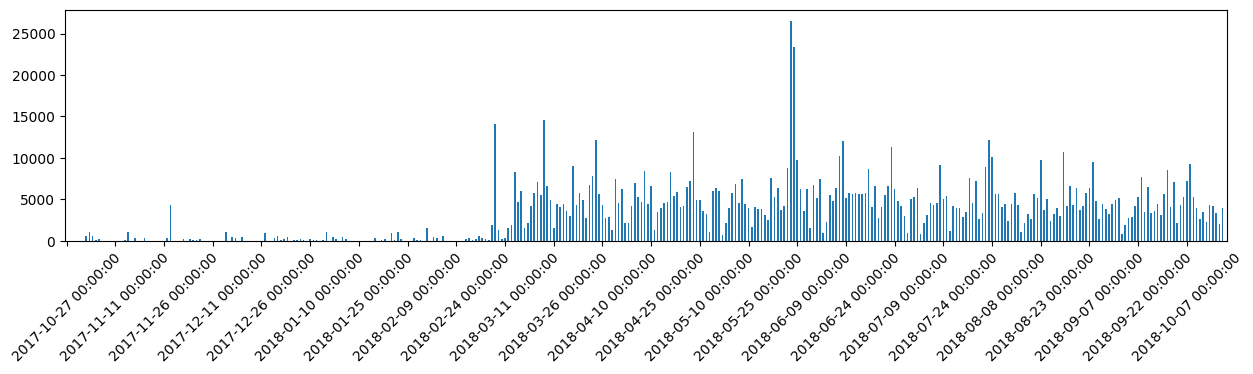

In [14]:
ax = final_data_fund['full_sum'].plot(kind='bar',figsize=(15, 3))

ax.set_xticks(ax.get_xticks()[::15])  #настраиваем подписи на оси x
plt.xticks(rotation=45)

plt.show()

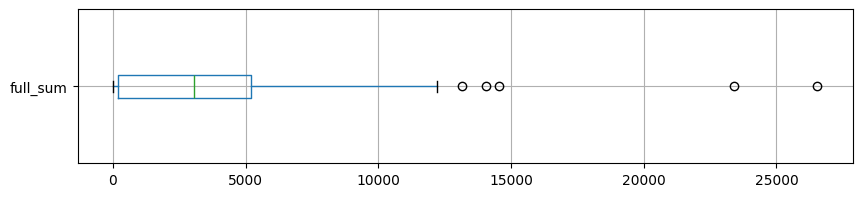

In [15]:
final_data_fund[['full_sum']].boxplot(figsize=(10, 2), vert=False);

In [16]:
# заменяем агрегированные дневные суммы из THRESHOLD_CONST перцентиля на медианное значение
threshold = final_data_fund['full_sum'].quantile(TRESHOLD_CONST)
print(threshold)
mean_full_sum = final_data_fund['full_sum'].median()
print(mean_full_sum)
final_data_fund.loc[final_data_fund['full_sum'] > threshold, 'full_sum'] = mean_full_sum

8954.5
3060.0


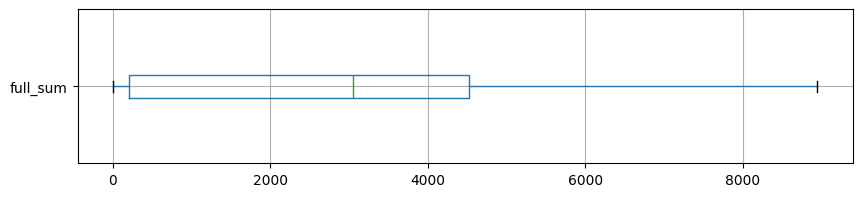

In [17]:
final_data_fund[['full_sum']].boxplot(figsize=(10, 2), vert=False);

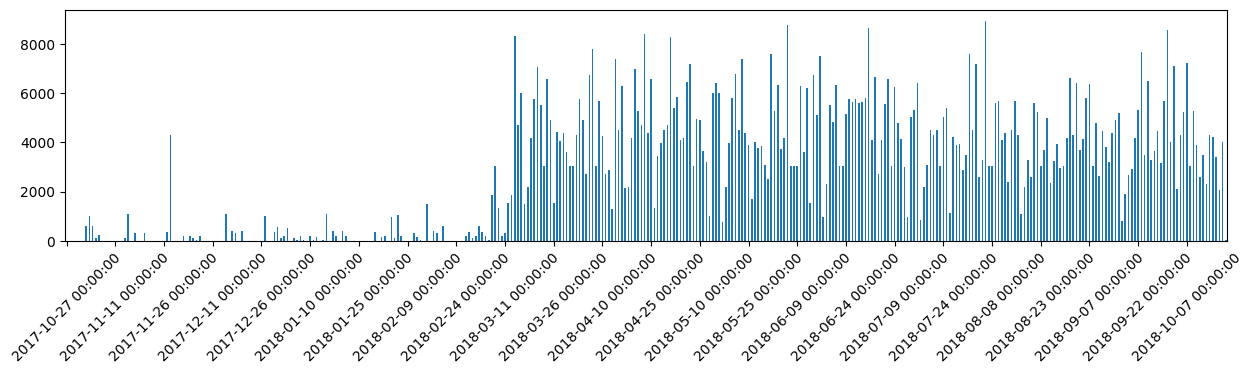

In [18]:
ax = final_data_fund['full_sum'].plot(kind='bar',figsize=(15, 3))

ax.set_xticks(ax.get_xticks()[::15])  # настрраиваем подписи по оси X
plt.xticks(rotation=45)

plt.show()

In [19]:
# сдвигаем целевую переменную на 1 назад, чтобы модель училась предсказывать по текущему значению признаков будущий день
final_data_fund_shifted = final_data_fund.copy()
final_data_fund_shifted['target_shifted'] = final_data_fund_shifted['full_sum'].shift(-1)

# убираем последнюю строку, так как она становится NaN из-за сдвига
final_data_fund_shifted = final_data_fund_shifted[:-1]

In [20]:
# определяем дату, начиная с которой данные будут отнесены к тестовой выборке
cutoff_date = final_data_fund_shifted.index.max() - pd.Timedelta(days=30) # последние 30 дней

# делим на train/test
final_train_data_fund = final_data_fund_shifted.loc[final_data_fund_shifted.index <= cutoff_date]
final_test_data_fund = final_data_fund_shifted.loc[final_data_fund_shifted.index > cutoff_date]

# проверяем размеры и даты
display(final_train_data_fund.shape, final_test_data_fund.shape)

print("Последняя тренировочная дата:", final_train_data_fund.index.max().date())
print("Первая тестовая дата:", final_test_data_fund.index.min().date())

(327, 22)

(30, 22)

Последняя тренировочная дата: 2018-09-18
Первая тестовая дата: 2018-09-19


<a id='Обучение-SARIMAX-и-прогнозирование-признака-для-catboost'></a> 
## Обучение SARIMAX и прогнозирование признака для catboost
[К содержанию](#К-содержанию)

In [21]:
# загружаем ряд с несдвинутым целевым признаком
y_train_sarimax_filled = final_data_fund.loc[:cutoff_date, 'full_sum'].copy()

# создаем пустую серию для хранения прогнозов
sarima_forecast = pd.Series(index=y_train_sarimax_filled.index, dtype=float)

# определяем минимальный размер выборки для начала обучения SARIMAX
min_full_size = 10

# заполняем начальные значения средними про предыдущим значениям
sarima_forecast.iloc[0] = y_train_sarimax_filled.iloc[0]  # первое значение как есть
 
for i in range(1, min_full_size):
    sarima_forecast.iloc[i] = y_train_sarimax_filled.iloc[:i].mean()

# задаем параметры модели
order = (1, 1, 2)
seasonal_order = (0, 0, 0, 0)

# запускаем обучение и прогнозирование, начиная с min_full_size
for i in range(min_full_size, len(y_train_sarimax_filled)):
    # используем все доступные данные для обучения
    train_series = y_train_sarimax_filled.iloc[:i].asfreq('D')
    
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False,
          maxiter=1000,
          optim_score='harvey',
          method='powell',
          cov_type='robust')
    
    # прогнозируем следующее значение и заменяем отрицательные значения на 0
    forecast = model.get_forecast(steps=1)
    predicted_value = forecast.predicted_mean.item()  # Достаем предсказанное значение
    predicted_value = max(predicted_value, 0)

    sarima_forecast.iloc[i] = predicted_value

# обнуляем первые значения, чтобы они не влияли на CatBoost
sarima_forecast.iloc[:min_full_size] = np.nan

print("Первые 15 прогнозов:")
display(sarima_forecast.head(15))

Первые 15 прогнозов:


2017-10-27      NaN
2017-10-28      NaN
2017-10-29      NaN
2017-10-30      NaN
2017-10-31      NaN
2017-11-01      NaN
2017-11-02      NaN
2017-11-03      NaN
2017-11-04      NaN
2017-11-05      NaN
2017-11-06     0.00
2017-11-07   477.01
2017-11-08     0.00
2017-11-09   223.52
2017-11-10    28.97
dtype: float64

In [22]:
# считаем метрику RMSE по прогнозу sarimax
rmse = np.sqrt(mean_squared_error(y_train_sarimax_filled.iloc[min_full_size:], sarima_forecast.iloc[min_full_size:]))
print(f"RMSE: {rmse:.2f}")

# считаем метрику SMAPE по прогнозу sarimax
smape_metrics = smape(y_train_sarimax_filled.iloc[min_full_size:], sarima_forecast.iloc[min_full_size:])
print(f"SMAPE: {smape_metrics:.2f}")

RMSE: 1579.78
SMAPE: 77.55


In [23]:
# добавляем прогноз sarimax как признак в датасет
final_train_data_fund = final_train_data_fund.copy()
final_train_data_fund['sarima_forecast'] = sarima_forecast.reindex(final_train_data_fund.index)
final_train_data_fund.head(15)

,full_sum,provider_1.0,provider_3.0,provider_4.0,provider_5.0,signup,count_payments,avg_payment,median_payment,min_payment,max_payment,day_of_week,week_number,rolling_avg_payment,lag_1_full_sum,lag_2_full_sum,lag_3_full_sum,lag_4_full_sum,lag_5_full_sum,lag_6_full_sum,lag_7_full_sum,target_shifted,sarima_forecast
2017-10-27,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,4,4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,300.00,0.00,NaN
2017-10-28,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,5,4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-10-29,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,6,5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-10-30,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,0,5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-10-31,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,1,5,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-11-01,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.00,2,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,600.00,NaN
2017-11-02,600.00,2.00,0.00,0.00,0.00,1.00,2,300.00,300.00,200.00,400.00,3,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1000.00,NaN
2017-11-03,1000.00,1.00,0.00,0.00,0.00,0.00,1,1000.00,1000.00,1000.00,1000.00,4,1,150.00,600.00,0.00,0.00,0.00,0.00,0.00,0.00,600.00,NaN
2017-11-04,600.00,2.00,0.00,0.00,0.00,0.00,2,300.00,300.00,100.00,500.00,5,1,650.00,1000.00,600.00,0.00,0.00,0.00,0.00,0.00,100.00,NaN
2017-11-05,100.00,1.00,0.00,0.00,0.00,1.00,1,100.00,100.00,100.00,100.00,6,1,650.00,600.00,1000.00,600.00,0.00,0.00,0.00,0.00,250.00,NaN


In [24]:
# посмотрим корреляцию прогноза и реальных значений
sarima_forecast.iloc[min_full_size:].corr(y_train_sarimax_filled.iloc[min_full_size:])

0.7775275934231487

<a id='Обучение-Catboost'></a> 
## Обучение Catboost
[К содержанию](#К-содержанию)

In [25]:
# подготовим обучение
cat_features = ['day_of_week', 'week_number']

# формируем X_train и y_train
X_train = final_train_data_fund.drop(['full_sum', 'target_shifted'], axis=1)
y_train = final_train_data_fund['target_shifted']

In [26]:
tss = TimeSeriesSplit(n_splits = 15)

# итоговый пайплайн
pipe_final = Pipeline([
    ('model', CatBoostRegressor(
        silent=True,
        random_state=RANDOM_STATE,
        cat_features=cat_features))
])

# сетка гиперпараметров
param_grid = [
    # CatBoostRegressor
    {
        'model__iterations': [100,200,500],
        'model__depth': [2,5,7],
        'model__learning_rate': [0.1,0.001],
        'model__l2_leaf_reg': [2],
        #'model__subsample': [0.8],
        'model__loss_function': ['RMSE'], # 'MAE', 'Quantile:alpha=0.8'],
        'model__max_bin': [256],
        'model__random_strength': [1],
        'model__early_stopping_rounds':[10]
        
    }
]

In [27]:
# полный перебор гиперпараметров с помощью GridSearchCV
grid_search = GridSearchCV(
    pipe_final,
    param_grid=param_grid,
    cv=tss,
    scoring={'neg_mean_squared_error': 'neg_mean_squared_error', 'smape': smape_scorer},
    refit='neg_mean_squared_error',
    n_jobs=-1,
    error_score='raise'
)

# обучение модели
model = grid_search.fit(X_train, y_train)

# выгружаем метрики
best_score_neg_mse = grid_search.best_score_
best_score_rmse = round(np.sqrt(-best_score_neg_mse), 3)
best_score_smape = round(-grid_search.cv_results_['mean_test_smape'][grid_search.best_index_], 3)  # Инверсия знака

# выводим результаты
print(f'Метрика RMSE лучшей модели на тренировочной выборке при кросс-валидации: {best_score_rmse}')
print(f'Метрика SMAPE лучшей модели на тренировочной выборке при кросс-валидации: {best_score_smape}')
print(f'Параметры лучшей модели: {grid_search.best_params_}')

Метрика RMSE лучшей модели на тренировочной выборке при кросс-валидации: 1635.517
Метрика SMAPE лучшей модели на тренировочной выборке при кросс-валидации: 77.355
Параметры лучшей модели: {'model__depth': 7, 'model__early_stopping_rounds': 10, 'model__iterations': 100, 'model__l2_leaf_reg': 2, 'model__learning_rate': 0.1, 'model__loss_function': 'RMSE', 'model__max_bin': 256, 'model__random_strength': 1}


In [28]:
# берем модель CatBoostRegressor из пайплайна
catboost_model = model.best_estimator_.named_steps["model"]

# получаем важность признаков
feature_importances = catboost_model.get_feature_importance()
feature_names = catboost_model.feature_names_

# преобразовываем в DataFrame, сортируем и выводим
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

                Feature  Importance
20      sarima_forecast       10.16
6           avg_payment        7.50
4                signup        7.23
14       lag_2_full_sum        7.20
17       lag_5_full_sum        6.76
19       lag_7_full_sum        6.46
15       lag_3_full_sum        6.29
12  rolling_avg_payment        6.18
0          provider_1.0        6.03
5        count_payments        5.93
18       lag_6_full_sum        5.88
16       lag_4_full_sum        5.44
3          provider_5.0        4.64
8           min_payment        3.83
13       lag_1_full_sum        3.71
2          provider_4.0        2.14
9           max_payment        1.88
7        median_payment        1.30
11          week_number        1.29
1          provider_3.0        0.17
10          day_of_week        0.00


<a id='Тестирование-модели-с-визуализацией-прогноза'></a> 
## Тестирование модели с визуализацией прогноза
[К содержанию](#К-содержанию)

In [29]:
# для теста catboost готовим прогнозы sarimax

# т.к будем обучать для тестовго прогнроза с добавлением каждый раз очередной точки - имеет смысл использовать тренировочный набор, тогда первые значения при обучении sarimax можно будет спокойно отбросить - т.к. нам нужны будут только последние значения из тестового набора
y_test_sarimax_filled = pd.concat([final_train_data_fund['full_sum'], final_test_data_fund['full_sum']])

# создаем пустую серию для хранения прогнозов
sarima_forecast_test = pd.Series(index=y_test_sarimax_filled.index, dtype=float)

# определяем минимальный размер выборки для sarimax
min_full_size = 10

# заполняем начальные значения средними про предыдущим значениям
sarima_forecast_test.iloc[0] = y_test_sarimax_filled.iloc[0]  # первое значение как есть
 
for i in range(1, min_full_size):
    sarima_forecast_test.iloc[i] = y_test_sarimax_filled.iloc[:i].mean()

# параметры модели задаются при обучении выше, сейчас используем те же параметры
#order = (1, 1, 2)
#seasonal_order = (0, 0, 0, 0)

# запускаем обучение и прогнозирование, начиная с min_full_size
for i in range(min_full_size, len(y_test_sarimax_filled)):
    # используем все доступные данные для обучения
    train_series = y_test_sarimax_filled.iloc[:i].asfreq('D')
    
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False,
          maxiter=1000,
          optim_score='harvey',
          method='powell',
          cov_type='robust')
    
    # прогнозируем следующее значение
    forecast = model.get_forecast(steps=1)
    predicted_value = forecast.predicted_mean.item()
    
    sarima_forecast_test.iloc[i] = predicted_value

# добавляем прогнозы sarimax в тестовый датафрейм
final_test_data_fund = final_test_data_fund.copy()
final_test_data_fund['sarima_forecast'] = sarima_forecast_test.reindex(final_test_data_fund.index)
final_test_data_fund.head(1)


,full_sum,provider_1.0,provider_3.0,provider_4.0,provider_5.0,signup,count_payments,avg_payment,median_payment,min_payment,max_payment,day_of_week,week_number,rolling_avg_payment,lag_1_full_sum,lag_2_full_sum,lag_3_full_sum,lag_4_full_sum,lag_5_full_sum,lag_6_full_sum,lag_7_full_sum,target_shifted,sarima_forecast
2018-09-19,2690.00,7.00,0.00,0.00,1.00,8.00,8,336.25,250.00,20.00,1000.00,2,3,175.00,1900.00,800.00,5200.00,4905.00,4400.00,3200.00,3800.00,2901.00,3577.14


Метрика RMSE  на тестовом наборе: 1548.07
Метрика SMAPE на тестовом наборе: 27.66


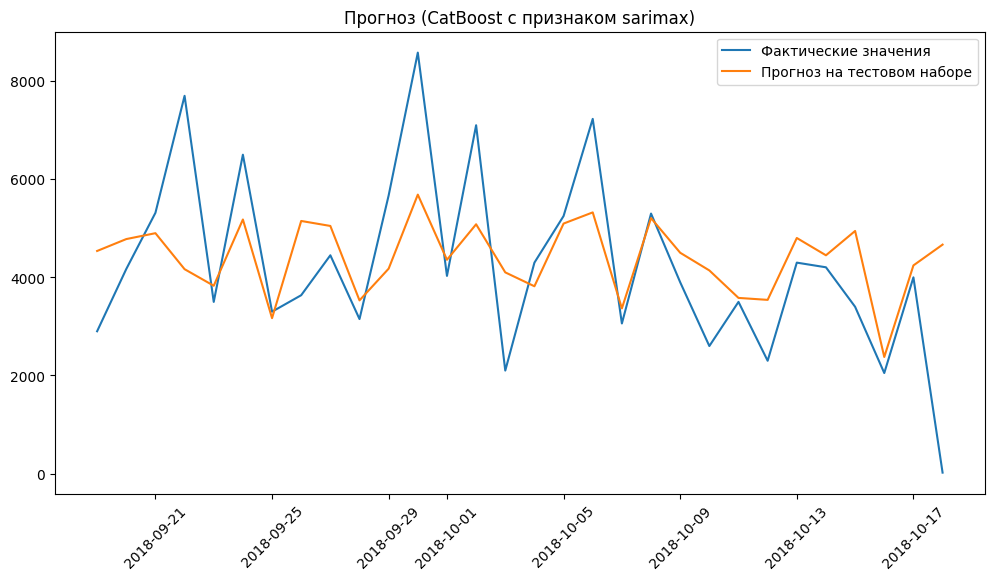

In [30]:
# тест catboost

# формируем X_test и y_test
X_test = final_test_data_fund.drop(['full_sum', 'target_shifted'], axis=1)
y_test = final_test_data_fund['target_shifted']

# переобучаем лучшую модель на всем тренировочном наборе
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)

# делаем прогноз и считаем метрики RMSE и SMAPE на тестовом наборе
y_test_pred = final_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
smape_metrics_test = smape(y_test, y_test_pred)

# выводим метрики
print(f'Метрика RMSE  на тестовом наборе: {rmse_test:.2f}')
print(f'Метрика SMAPE на тестовом наборе: {smape_metrics_test:.2f}')

# смотрим на графике 
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Фактические значения')
plt.plot(y_test.index, y_test_pred, label='Прогноз на тестовом наборе')
plt.xticks(rotation=45)
plt.title('Прогноз (CatBoost c признаком sarimax)')
plt.legend()
plt.show()


In [31]:
y_test.describe()

count     30.00
mean    4250.57
std     1854.26
min       20.00
25%     3187.50
50%     4015.00
75%     5287.50
max     8580.00
Name: target_shifted, dtype: float64